## Уменьшение размерности данных

Источник данных: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

Для анализа выбраны данные о состоянии здоровья 2149 пациентов, которым был поставлен/не поставлен диагноз болезни Альцгеймера. Данные содержат факторы образа жизни, историю болезни, клинические измерения, когнитивные и функциональные оценки, симптомы и результат диагностики.

<details> <summary> Описание признаков</summary>

| Признак | Диапазон / Значения | Описание |
| :--- | :--- | :--- |
| PatientID | 4751 – 6900 | Уникальный идентификатор пациента |
| Age | 60 – 90 лет | Возраст пациента |
| Gender | 0 = Мужской, 1 = Женский | Пол пациента |
| Ethnicity | 0 = Caucasian, 1 = African American, 2 = Asian, 3 = Other | Этническая принадлежность |
| EducationLevel | 0 = None, 1 = High School, 2 = Bachelor's, 3 = Higher | Уровень образования |
| BMI | 15 – 40 | Индекс массы тела |
| Smoking | 0 = Нет, 1 = Да | Курение |
| AlcoholConsumption | 0 – 20 единиц в неделю | Потребление алкоголя |
| PhysicalActivity | 0 – 10 часов в неделю | Физическая активность |
| DietQuality | 0 – 10 (выше = лучше) | Качество диеты |
| SleepQuality | 4 – 10 (выше = лучше) | Качество сна |
| FamilyHistoryAlzheimers | 0 = Нет, 1 = Да | Семейная история болезни Альцгеймера |
| CardiovascularDisease | 0 = Нет, 1 = Да | Сердечно-сосудистые заболевания |
| Diabetes | 0 = Нет, 1 = Да | Диабет |
| Depression | 0 = Нет, 1 = Да | Депрессия |
| HeadInjury | 0 = Нет, 1 = Да | Травма головы в анамнезе |
| Hypertension | 0 = Нет, 1 = Да | Гипертония |
| SystolicBP | 90 – 180 мм рт. ст. | Систолическое артериальное давление |
| DiastolicBP | 60 – 120 мм рт. ст. | Диастолическое артериальное давление |
| CholesterolTotal | 150 – 300 мг/дл | Общий холестерин |
| CholesterolLDL | 50 – 200 мг/дл | LDL-холестерин («плохой») |
| CholesterolHDL | 20 – 100 мг/дл | HDL-холестерин («хороший») |
| CholesterolTriglycerides | 50 – 400 мг/дл | Триглицериды |
| MMSE | 0 – 30 (ниже = хуже) | Mini-Mental State Examination |
| FunctionalAssessment | 0 – 10 (ниже = хуже) | Функциональная оценка |
| MemoryComplaints | 0 = Нет, 1 = Да | Жалобы на память |
| BehavioralProblems | 0 = Нет, 1 = Да | Поведенческие проблемы |
| ADL | 0 – 10 (ниже = хуже) | Activities of Daily Living - Оценка повседневной активности|
| Confusion | 0 = Нет, 1 = Да | Спутанность сознания |
| Disorientation | 0 = Нет, 1 = Да | Дезориентация |
| PersonalityChanges | 0 = Нет, 1 = Да | Изменения личности |
| DifficultyCompletingTasks | 0 = Нет, 1 = Да | Трудности с выполнением задач |
| Forgetfulness | 0 = Нет, 1 = Да | Забывчивость |
| Diagnosis | 0 = Нет, 1 = Да | Диагноз болезни Альцгеймера |
| DoctorInCharge | "XXXConfid" для всех | Конфиденциальная информация о враче |

</details>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

In [2]:
data = pd.read_csv("data/alzheimers_disease_data.csv", index_col="PatientID")

In [3]:
data.sample(7)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
PatientID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
6471,90,1,1,1,17.235990,0,6.954826,1.768237,8.647668,7.123329,0,0,0,0,0,0,147,118,249.363535,100.450926,76.157678,330.942806,3.070327,7.937030,0,1,3.377024,0,0,1,0,0,1,XXXConfid
5747,83,0,3,1,32.980091,0,18.802521,7.427899,2.280809,9.815333,0,0,0,0,0,0,98,95,248.227785,183.340669,76.839936,252.434781,13.331886,4.044085,0,0,8.797415,0,0,0,0,0,0,XXXConfid
5166,69,1,0,1,32.385379,0,16.652104,1.868168,6.238113,6.920993,0,0,1,0,0,0,150,94,280.154124,79.576736,55.485196,399.684311,1.680447,1.591742,0,0,5.502752,0,0,0,0,1,0,XXXConfid
5533,82,1,3,2,24.822461,0,1.629756,5.804273,1.474693,7.059890,0,0,0,0,0,0,177,85,192.047730,173.251706,52.517667,381.399413,15.748758,6.565321,0,0,7.255715,1,0,0,0,1,0,XXXConfid
6728,66,0,0,2,26.831952,0,9.170072,4.568941,2.780591,8.766244,0,0,0,1,0,0,157,117,152.078004,155.607464,81.268274,239.587850,10.636262,8.795186,0,0,5.436132,1,0,0,1,0,0,XXXConfid
6503,87,0,1,3,36.789829,1,13.477652,6.664229,0.024543,8.419375,0,0,0,0,0,0,140,102,173.103976,140.086290,89.697785,284.828116,8.066373,6.263250,0,0,2.486107,0,0,0,0,1,0,XXXConfid
4906,82,1,3,1,31.611213,0,8.351135,7.823262,1.947848,6.145071,1,1,0,0,0,0,149,79,164.120043,188.249538,28.116803,162.889613,17.678319,5.242832,0,0,2.783821,0,0,0,0,1,0,XXXConfid


In [4]:
data.nunique()

Age                            31
Gender                          2
Ethnicity                       4
EducationLevel                  4
BMI                          2149
Smoking                         2
AlcoholConsumption           2149
PhysicalActivity             2149
DietQuality                  2149
SleepQuality                 2149
FamilyHistoryAlzheimers         2
CardiovascularDisease           2
Diabetes                        2
Depression                      2
HeadInjury                      2
Hypertension                    2
SystolicBP                     90
DiastolicBP                    60
CholesterolTotal             2149
CholesterolLDL               2149
CholesterolHDL               2149
CholesterolTriglycerides     2149
MMSE                         2149
FunctionalAssessment         2149
MemoryComplaints                2
BehavioralProblems              2
ADL                          2149
Confusion                       2
Disorientation                  2
PersonalityCha

Уберем признак DoctorInCharge, так как он всегда содержит одно неинформативное значение.

Также уберем признак Diagnosis, так как это целевая переменная.

In [5]:
df = data.drop(columns=["Diagnosis", "DoctorInCharge"])

df.select_dtypes("object") # категориальных признаков нет

""
PatientID
4751
4752
4753
4754
4755
...
6895
6896
6897


In [6]:
df.isna().sum().sum() # пропусков нет

np.int64(0)

Нормализация переменных - отмасштабируем все значения, чтобы их мат ожидание стало 0, а стандартное отклонение 1:

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=scaler.get_feature_names_out())

In [8]:
scaled_df.head(3)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,-0.212368,-1.012644,-0.700408,0.788833,-0.655225,-0.636784,0.565923,0.492525,-1.253593,1.119918,-0.580753,-0.410573,2.373334,1.996517,-0.319455,-0.418281,0.298159,-1.014750,0.403677,-1.572661,-1.114429,-0.648199,0.779037,0.497506,-0.512477,-0.431257,-1.104434,-0.508131,-0.433531,-0.421348,2.302619,-0.657048
1,1.567757,-1.012644,-0.700408,-1.422782,-0.114751,-0.636784,-0.954895,0.945093,-1.538442,0.056836,-0.580753,-0.410573,-0.421348,-0.500872,-0.319455,-0.418281,-0.742572,-1.469595,0.140248,1.593119,0.845730,0.650721,0.680297,0.704907,-0.512477,-0.431257,-0.810601,-0.508131,-0.433531,-0.421348,-0.434288,1.521959
2,-0.212368,-1.012644,2.311955,-0.316974,-1.366428,-0.636784,1.653006,1.023896,-1.088855,1.487380,1.721901,-0.410573,-0.421348,-0.500872,-0.319455,-0.418281,-1.359301,1.486898,1.386812,0.668569,0.445615,-1.418585,-0.859222,0.281813,-0.512477,-0.431257,0.724491,-0.508131,2.306640,-0.421348,2.302619,-0.657048


### Метод главных компонент

Уменьшим размерность данных до 2 и посмотрим полученную долю объясненной дисперсии

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # уменьшаем до 2 компонент
pca_2d_df = pca.fit_transform(scaled_df)
print(pca.explained_variance_ratio_)
print("Общая дисперсия:", sum(pca.explained_variance_ratio_))

[0.03782383 0.03742685]
Общая дисперсия: 0.07525068478496524


Данные плохо сжались -- полученные две размерности покрывают только 7,5% общей дисперсии.

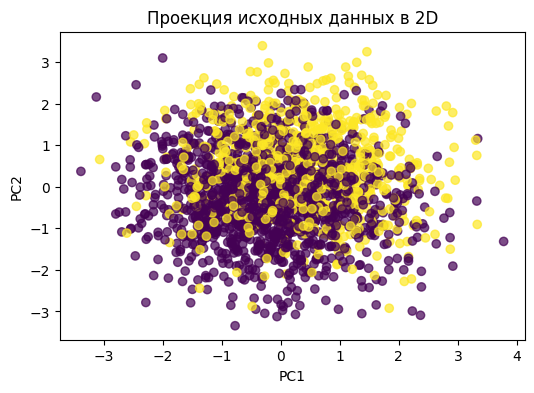

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(pca_2d_df[:, 0], pca_2d_df[:, 1], c=data["Diagnosis"], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Проекция исходных данных в 2D")
plt.show()

Классы неразделимы в случае проекции на две оси.

Уменьшим размерность до 3.

In [11]:
pca_3d = PCA(n_components=3)
pca_3d_df = pca_3d.fit_transform(scaled_df)

print("Доли дисперсий в новых компонентах:", pca_3d.explained_variance_ratio_)
print("Общая дисперсия:", sum(pca_3d.explained_variance_ratio_))

Доли дисперсий в новых компонентах: [0.03782383 0.03742685 0.03692534]
Общая дисперсия: 0.11217602551708583


Результат заметно не улучшился, всего 11% дисперсии объясняют новые признаки.

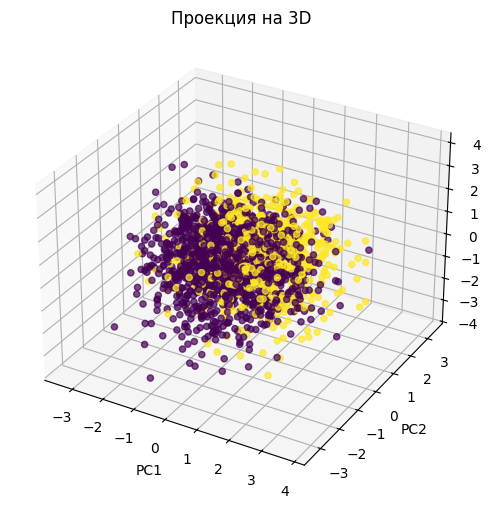

In [12]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(pca_3d_df[:, 0], pca_3d_df[:, 1], pca_3d_df[:, 2], c=data["Diagnosis"], alpha=0.7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("Проекция на 3D")
plt.show()

Классы по-прежнему смешаны.

Уменьшим размерность по заданной доле объясненной дисперсии -- алгоритм сам выберет нужную новую размерность:

In [13]:
variance = 0.80
pca = PCA(variance)
pca_auto = pca.fit_transform(scaled_df)

print("Новое кол-во компонент:", pca.n_components_)
print("Доли дисперсий в новых компонентах:", pca.explained_variance_ratio_)
print("Общая дисперсия:", sum(pca.explained_variance_ratio_))

Новое кол-во компонент: 25
Доли дисперсий в новых компонентах: [0.03782383 0.03742685 0.03692534 0.03666648 0.03552492 0.03517358
 0.03460371 0.03426568 0.03398605 0.0337104  0.03294712 0.03257981
 0.03235732 0.0317842  0.03173219 0.03112633 0.03074781 0.03028001
 0.03001554 0.02989731 0.02967545 0.02955795 0.02883506 0.0285625
 0.02819059]
Общая дисперсия: 0.8143960629719983


25 признаков достаточно для описания 81% дисперсии исходных данных

### Дискриминантный анализ

Уменьшим размерность до 1 и посмотрим на разделение классов вдоль полученной оси

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

y = data["Diagnosis"]

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(scaled_df, y)

print("Средние по классам:")
pd.DataFrame(lda.means_, columns=scaled_df.columns, index=lda.classes_)

Средние по классам:


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,0.00406,0.015515,0.010934,0.032522,-0.019486,0.003599,0.005635,-0.004398,-0.006292,0.041829,0.024336,-0.023293,0.023306,0.004359,0.015838,-0.025949,0.011551,-0.003915,-0.004730,0.023653,-0.031499,-0.01677,0.175402,0.269915,-0.226897,-0.165952,0.245836,0.014192,0.018232,0.015258,-0.006708,0.000262
1,-0.00742,-0.028356,-0.019984,-0.059437,0.035613,-0.006577,-0.010299,0.008037,0.011499,-0.076447,-0.044477,0.042572,-0.042595,-0.007967,-0.028946,0.047425,-0.021110,0.007155,0.008645,-0.043228,0.057569,0.03065,-0.320570,-0.493306,0.414685,0.303299,-0.449298,-0.025937,-0.033322,-0.027886,0.012260,-0.000479


In [33]:
print("Коэффициенты:")
pd.DataFrame(lda.scalings_, index=scaled_df.columns, columns=[f"Коэффициент{i+1}" for i in range(lda.scalings_.shape[1])])

Коэффициенты:


,Коэффициент1
Age,-0.058204
Gender,-0.006506
Ethnicity,-0.017003
EducationLevel,-0.046011
BMI,-0.012116
Smoking,-0.052516
AlcoholConsumption,-0.028159
PhysicalActivity,-0.002143
DietQuality,0.015916
SleepQuality,-0.058127


In [35]:
print("Объясненная дисперсия:")
lda.explained_variance_ratio_

Объясненная дисперсия:


array([1.])

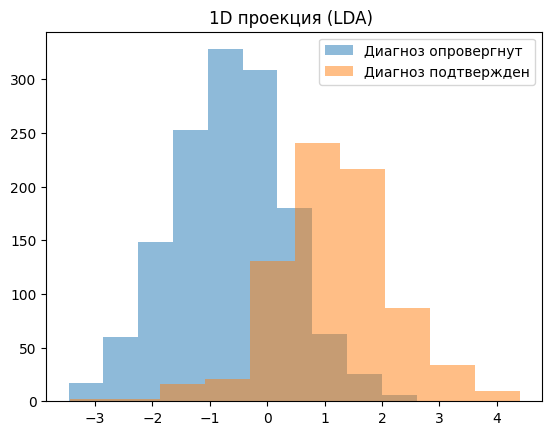

In [23]:
plt.hist(X_lda[y==0], alpha=0.5, label="Диагноз опровергнут")
plt.hist(X_lda[y==1], alpha=0.5, label="Диагноз подтвержден")

plt.legend()
plt.title("1D проекция (LDA) ")
plt.show()

Качественно разделить два класса в одномерном пространстве не получится, т.к. значения значительной части объектов обоих классов пересекаются в районе от 0 до 1.5

### Факторный анализ

Выделим 3 новых признака

In [39]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=3)
X_fa = fa.fit_transform(scaled_df)

In [43]:
factors = pd.DataFrame(fa.components_.T, index=scaled_df.columns, columns=["Factor1", "Factor2", "Factor3"])

Отсортируем признаки по значениям всех факторов

In [45]:
factors[["Factor1"]].sort_values(["Factor1"], ascending=False)

,Factor1
Disorientation,0.258107
FamilyHistoryAlzheimers,0.152426
SystolicBP,0.124975
MMSE,0.100967
CardiovascularDisease,0.100257
Gender,0.071717
Confusion,0.068806
CholesterolTotal,0.063446
Hypertension,0.062371
CholesterolLDL,0.050269


Наибольшие значения первого скрытого фактора имеют такие показатели как 